# Hospital Readmission Prediction — Diabetes 130-US Hospitals (1999–2008)

**Objective:** Predict whether a diabetic patient will be readmitted to hospital within 30 days of discharge.  
**Dataset:** [UCI ML Repository — Diabetes 130-US Hospitals](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)  
**Target variable:** `readmitted` → binary (1 = readmitted within 30 days, 0 = otherwise)

---
### Notebook Structure
| # | Section |
|---|---------|
| 1 | Imports |
| 2 | Data Loading |
| 3 | Data Cleaning |
| 4 | Missing Value Analysis |
| 5 | Feature Engineering (pre-EDA) |
| 6 | Statistical Tests |
| 7 | Exploratory Data Analysis |
| 8 | Feature Engineering (post-EDA) |
| 9 | Modelling Pipeline |
| 10 | Results & Evaluation |

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind, f_oneway, pearsonr, spearmanr
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier
import lightgbm as lgb

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:g}".format)

## 2. Data Loading

In [2]:
# Update this path to point to your local copy of diabetic_data.csv
DATA_PATH = "/Users/jyoteermaya/Documents/Great_Learning/GL_Python/Capstone Project/diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv"

df_med = pd.read_csv(DATA_PATH)
print(f"Shape: {df_med.shape}")
df_med.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## 3. Data Cleaning

Steps performed:
- Remove rows where primary/secondary/tertiary diagnosis is unknown (`?`)
- Replace remaining `?` placeholders with `NaN`
- Cast ID columns that represent categories as `object` dtype

In [4]:
# Remove rows where any diagnosis code is unknown
df_med = df_med[~(
    (df_med['diag_1'] == "?") |
    (df_med['diag_2'] == "?") |
    (df_med['diag_3'] == "?")
)]

# Replace '?' placeholder with NaN throughout
df_med.replace("?", np.nan, inplace=True)

# These IDs are categorical — stored as integers but should be treated as labels
for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    df_med[col] = df_med[col].astype("object")

print(f"Shape after cleaning: {df_med.shape}")

Shape after cleaning: (100244, 50)


## 4. Missing Value Analysis

Columns with high missing rates are dropped rather than imputed:
- `weight` (97% missing), `payer_code` (40% missing) — dropped
- `medical_specialty` (49%), `max_glu_serum` (94%), `A1Cresult` (83%) — dropped
- `encounter_id`, `patient_nbr` — identifiers with no predictive value, dropped
- `race` — filled with `"Unknown"`
- Diagnosis columns (`diag_1–3`) — filled with `"Unknown"`
- 3 rows with `gender == "Unknown/Invalid"` — removed

In [5]:
missing_df = pd.DataFrame({
    "missing_count":   df_med.isnull().sum(),
    "missing_percent": df_med.isnull().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_df[missing_df.missing_count > 0]

,missing_count,missing_percent
weight,97073,96.8367
max_glu_serum,94981,94.7498
A1Cresult,83645,83.4414
medical_specialty,49482,49.3616
payer_code,39455,39.359
race,2191,2.18567


In [6]:
# Drop high-missing and identifier columns
drop_cols = [
    "weight", "payer_code", "encounter_id", "patient_nbr",
    "medical_specialty", "max_glu_serum", "A1Cresult"
]
df_med.drop(columns=drop_cols, inplace=True)

# Fill / remove remaining missing values
df_med["race"].fillna("Unknown", inplace=True)
df_med = df_med[df_med["gender"] != "Unknown/Invalid"]

for col in ["diag_1", "diag_2", "diag_3"]:
    df_med[col].fillna("Unknown", inplace=True)

print(f"Shape after dropping columns and rows: {df_med.shape}")
print(f"Remaining nulls: {df_med.isnull().sum().sum()}")

Shape after dropping columns and rows: (100241, 43)
Remaining nulls: 0


## 5. Feature Engineering (pre-EDA)

### 5.1 Target & Age Encoding

In [7]:
# Binary target: 1 = readmitted within 30 days, 0 = otherwise
df_med["readmitted"] = (df_med["readmitted"] == "<30").astype(int)
print("Target distribution:")
print(df_med["readmitted"].value_counts(normalize=True).round(3))

# Encode medication-change flag
df_med["change"] = df_med["change"].map({"No": 0, "Ch": 1})

# Order age as an ordinal category for display purposes
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]
df_med["age"] = pd.Categorical(df_med["age"], categories=age_order, ordered=True)

Target distribution:
readmitted
0   0.888
1   0.112
Name: proportion, dtype: float64


### 5.2 Medication Columns — Chi-Square Feature Selection

In [8]:
# Identify all medication columns
med_pattern = (
    "metformin|repaglinide|nateglinide|chlorpropamide|glimepiride|"
    "acetohexamide|tolbutamide|acarbose|miglitol|insulin|glipizide|"
    "troglitazone|glyburide|tolazamide|pioglitazone|rosiglitazone|"
    "examide|citoglipton|glyburide-metformin|glipizide-metformin|"
    "glimepiride-pioglitazone|metformin-rosiglitazone|metformin-pioglitazone"
)
med_cols = df_med.columns[df_med.columns.str.contains(med_pattern, case=False)]

# Chi-square test: keep only medications significantly associated with readmission
chi2_results = []
for col in med_cols:
    table = pd.crosstab(df_med[col], df_med["readmitted"])
    stat, pval, dof, _ = chi2_contingency(table)
    chi2_results.append({"column": col, "chi2": stat, "p_value": pval})

chi2_df = pd.DataFrame(chi2_results).sort_values("p_value")
sig_meds  = chi2_df[chi2_df["p_value"] < 0.05]["column"].tolist()
drop_meds = chi2_df[chi2_df["p_value"] >= 0.05]["column"].tolist()

print(f"Significant medications (kept):  {sig_meds}")
print(f"Non-significant (dropped): {drop_meds}")

df_med.drop(columns=drop_meds, inplace=True)

Significant medications (kept):  ['insulin', 'metformin', 'repaglinide', 'glipizide']
Non-significant (dropped): ['glimepiride', 'miglitol', 'pioglitazone', 'rosiglitazone', 'glyburide', 'acarbose', 'chlorpropamide', 'tolbutamide', 'nateglinide', 'glyburide-metformin', 'tolazamide', 'acetohexamide', 'metformin-rosiglitazone', 'troglitazone', 'examide', 'citoglipton', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-pioglitazone']


In [9]:
# Encode significant medication columns: any dose change → 1, no change/not prescribed → 0
for col in sig_meds:
    df_med[col] = df_med[col].replace({"Up": 1, "Down": 1, "Steady": 0, "No": 0})
    df_med[col] = df_med[col].astype("category")

# Drop any remaining columns that have only one unique value (no signal)
cat_desc = df_med.select_dtypes(exclude="number").describe().T
single_value_cols = cat_desc[cat_desc["unique"] < 2].index.tolist()
if single_value_cols:
    print(f"Dropping single-value columns: {single_value_cols}")
    df_med.drop(columns=single_value_cols, inplace=True)

print(f"Shape: {df_med.shape}")

Shape: (100241, 24)


### 5.3 ICD-9 Diagnosis Grouping

In [10]:
def diag_group(code):
    """Map an ICD-9 code string to a broad disease category."""
    try:
        c = float(code)
        if   390 <= c < 460:  return "circulatory"
        elif 460 <= c < 520:  return "respiratory"
        elif 250 <= c < 260:  return "diabetes"      # full 250.x range
        elif 520 <= c < 580:  return "digestive"
        elif 800 <= c < 1000: return "injury"
        elif 140 <= c < 240:  return "neoplasms"
        else:                 return "other"
    except (ValueError, TypeError):
        return "other"

for col in ["diag_1", "diag_2", "diag_3"]:
    df_med[col + "_group"] = df_med[col].apply(diag_group)

df_med.drop(columns=["diag_1", "diag_2", "diag_3"], inplace=True)
print(df_med["diag_1_group"].value_counts())

diag_1_group
other          32140
circulatory    30206
respiratory    10328
digestive       9098
diabetes        8245
injury          6834
neoplasms       3390
Name: count, dtype: int64


### 5.4 Admission / Discharge / Source Encoding

In [11]:
# Admission type: 8 codes → 4 meaningful groups
admission_type_map = {1: "Emergency", 2: "Urgent", 3: "Elective"}
df_med["admission_type_id"] = df_med["admission_type_id"].apply(
    lambda x: admission_type_map.get(x, "Other")
)

# Discharge disposition: 30 codes → 6 meaningful groups
def map_disposition(x):
    if x in (1, 13):                          return "Home"
    elif x in (2, 9, 12, 14, 15):             return "Hospital_Transfer"
    elif x in (3, 4, 5, 22, 23, 24, 27, 28, 29, 30): return "Care_Facility"
    elif x in (6, 8):                          return "Home_Health_Service"
    elif x == 7:                               return "AMA"
    else:                                      return "Other"

df_med["discharge_disposition_id"] = df_med["discharge_disposition_id"].apply(map_disposition)

# Admission source: 26 codes → 5 meaningful groups
def map_admission_source(x):
    if x in (1, 2, 3):                         return "Referral"
    elif x == 7:                                return "Emergency"
    elif x in (4, 5, 6, 10, 18, 22, 25, 26):  return "Transfer"
    elif x == 19:                               return "Home_Health_Readmission"
    else:                                       return "Other"

df_med["admission_source_id"] = df_med["admission_source_id"].apply(map_admission_source)

print(f"Shape: {df_med.shape}")

Shape: (100241, 24)


## 6. Statistical Tests

Confirming that key features are statistically associated with the readmission target.

In [12]:
tests = {
    "DiabetesMed vs Readmitted (Chi-square)": lambda: chi2_contingency(
        pd.crosstab(df_med["diabetesMed"], df_med["readmitted"])
    )[:2],
    "Admission type vs Readmitted (Chi-square)": lambda: chi2_contingency(
        pd.crosstab(df_med["admission_type_id"], df_med["readmitted"])
    )[:2],
}

for name, fn in tests.items():
    stat, p = fn()
    print(f"{name}")
    print(f"  Statistic={stat:.2f}  p={p:.2e}  → {'Significant ✓' if p < 0.05 else 'Not significant'}\n")

# T-test: time_in_hospital by readmission group
t, p = ttest_ind(
    df_med[df_med["readmitted"] == 1]["time_in_hospital"],
    df_med[df_med["readmitted"] == 0]["time_in_hospital"],
    equal_var=False
)
print(f"Time-in-hospital by readmission (Welch t-test)")
print(f"  t={t:.2f}  p={p:.2e}  → {'Significant ✓' if p < 0.05 else 'Not significant'}\n")

# ANOVA: time_in_hospital across age groups
groups = [g["time_in_hospital"].dropna() for _, g in df_med.groupby("age")]
f, p = f_oneway(*groups)
print(f"Time-in-hospital across age groups (One-way ANOVA)")
print(f"  F={f:.2f}  p={p:.2e}  → {'Significant ✓' if p < 0.05 else 'Not significant'}\n")

# Correlation: lab procedures vs time in hospital
r, p = pearsonr(df_med["num_lab_procedures"], df_med["time_in_hospital"])
print(f"Lab procedures ↔ Time-in-hospital (Pearson r)")
print(f"  r={r:.3f}  p={p:.2e}  → {'Significant ✓' if p < 0.05 else 'Not significant'}")

DiabetesMed vs Readmitted (Chi-square)
  Statistic=71.44  p=2.85e-17  → Significant ✓

Admission type vs Readmitted (Chi-square)
  Statistic=20.19  p=1.55e-04  → Significant ✓

Time-in-hospital by readmission (Welch t-test)
  t=13.49  p=3.02e-41  → Significant ✓

Time-in-hospital across age groups (One-way ANOVA)
  F=110.06  p=2.05e-206  → Significant ✓

Lab procedures ↔ Time-in-hospital (Pearson r)
  r=0.319  p=0.00e+00  → Significant ✓


## 7. Exploratory Data Analysis

### 7.1 Target Class Distribution

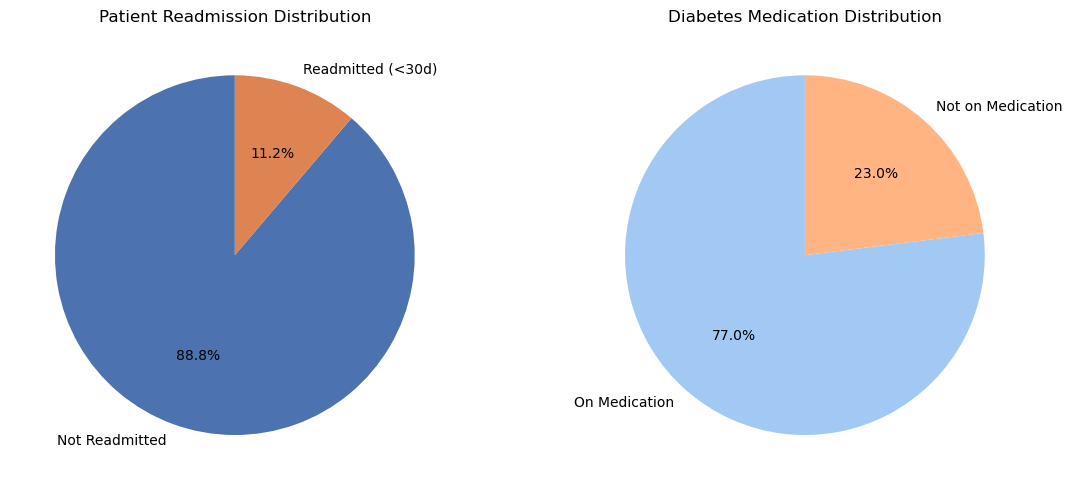

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Readmission
counts = df_med["readmitted"].value_counts()
axes[0].pie(counts, labels=["Not Readmitted", "Readmitted (<30d)"],
            autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("deep"))
axes[0].set_title("Patient Readmission Distribution")

# Diabetes medication
dm_counts = df_med["diabetesMed"].value_counts()
axes[1].pie(dm_counts, labels=["On Medication", "Not on Medication"],
            autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("pastel"))
axes[1].set_title("Diabetes Medication Distribution")

plt.tight_layout()
plt.show()

### 7.2 Numerical Feature Distributions & Correlations

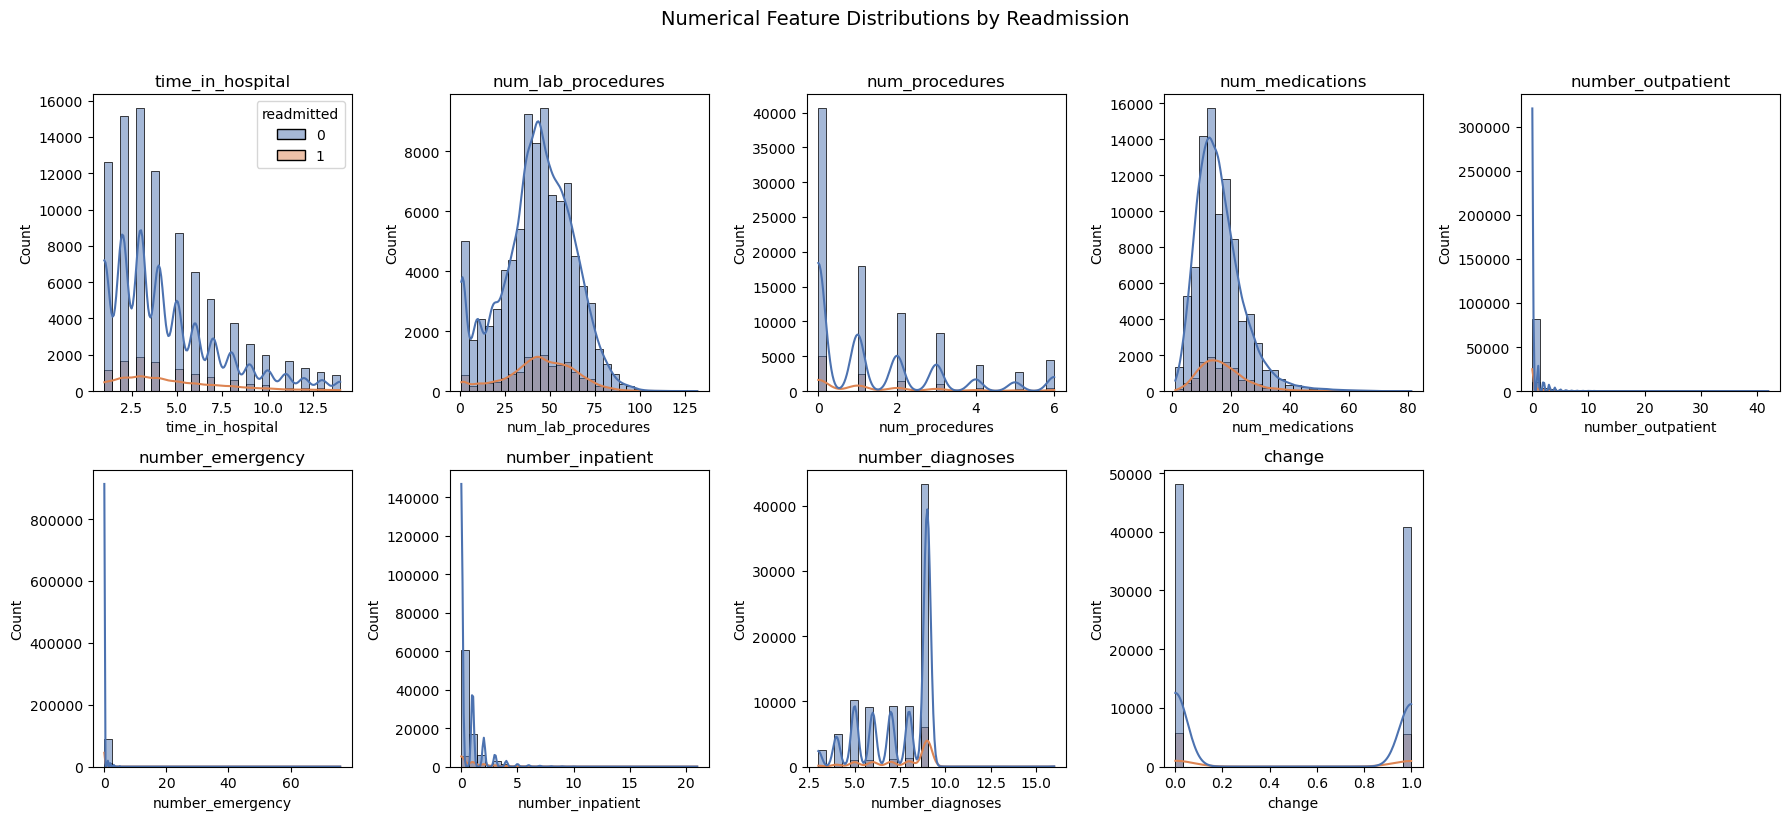

In [14]:
num_cols = df_med.select_dtypes(include="number").columns.drop("readmitted")

fig, axes = plt.subplots(2, len(num_cols) // 2 + 1, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_med, x=col, hue="readmitted", kde=True,
                 ax=axes[i], palette="deep", bins=30, legend=(i == 0))
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Feature Distributions by Readmission", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

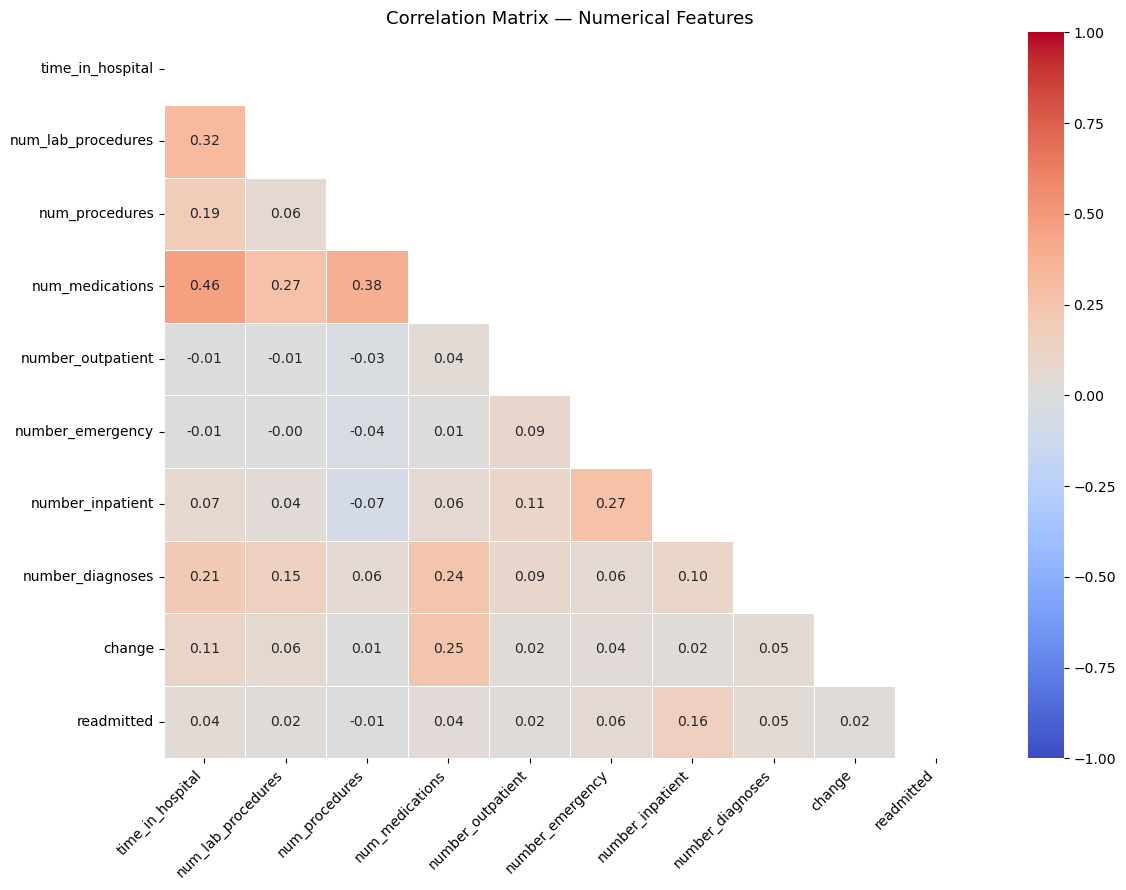

In [15]:
corr = df_med.select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmax=1, vmin=-1,
            annot_kws={"size": 10}, linewidths=0.5)
plt.title("Correlation Matrix — Numerical Features", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 7.3 Categorical Features vs Readmission

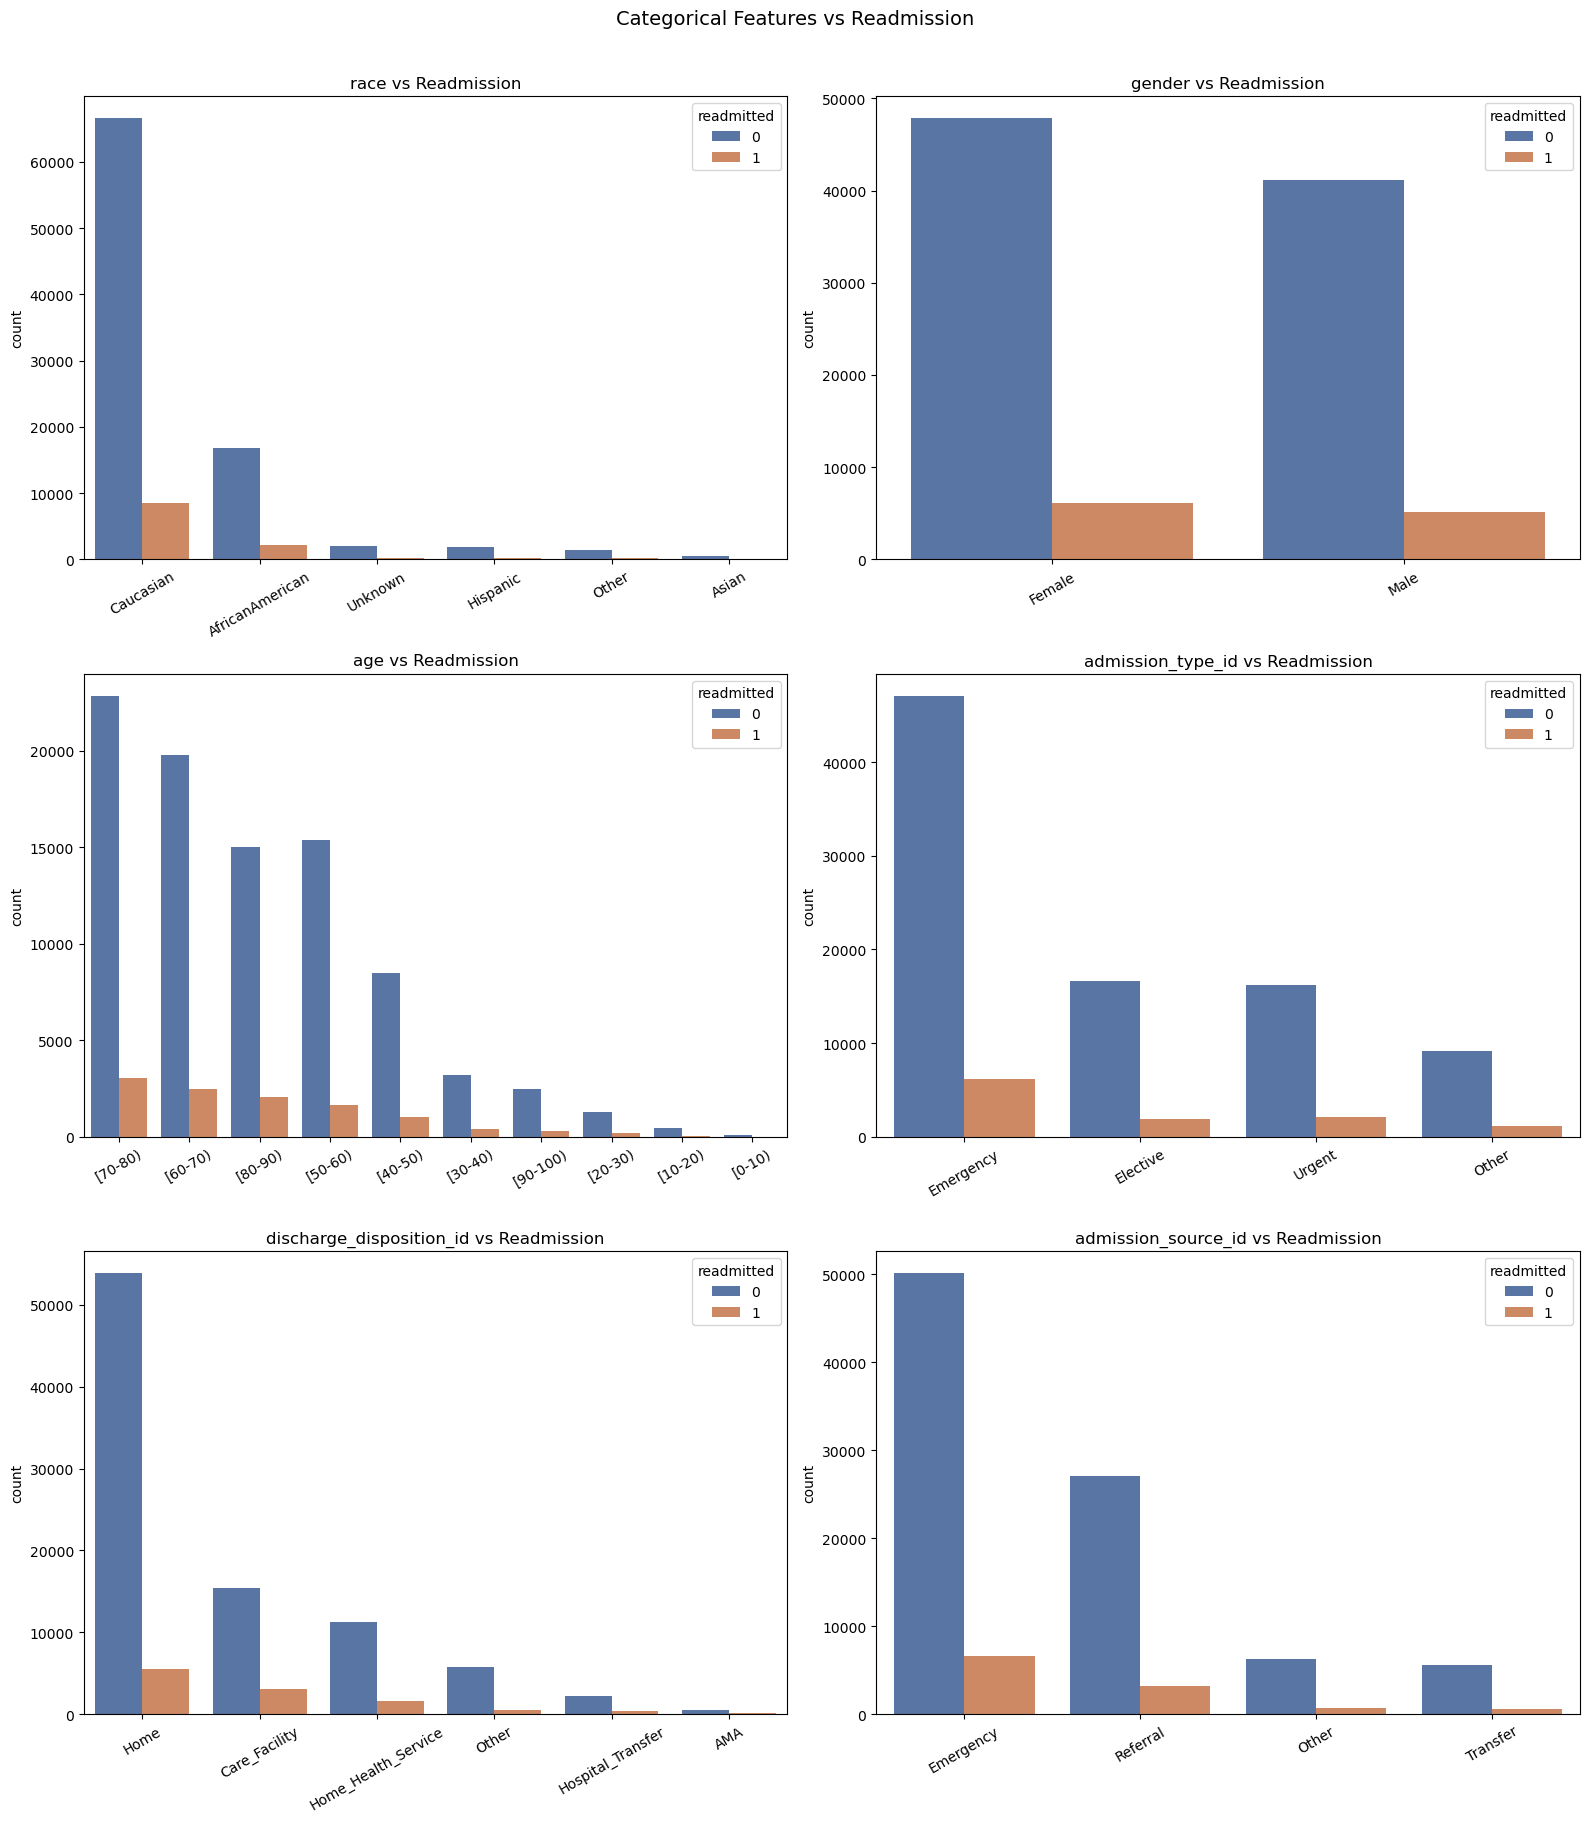

In [16]:
cat_features = [
    "race", "gender", "age", "admission_type_id",
    "discharge_disposition_id", "admission_source_id"
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    order = df_med[col].value_counts().index
    sns.countplot(data=df_med, x=col, hue="readmitted",
                  order=order, ax=axes[i], palette="deep")
    axes[i].set_title(f"{col} vs Readmission")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].set_xlabel("")

plt.suptitle("Categorical Features vs Readmission", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Key observations:**
1. Emergency admissions have the highest readmission rate
2. Patients aged 40–90 account for the majority of readmissions  
3. Patients discharged home or to home health services show higher readmission risk  
4. Patients on diabetes medication are more frequently readmitted (selection bias: sicker patients)

### 7.4 Outlier Check — Box Plots

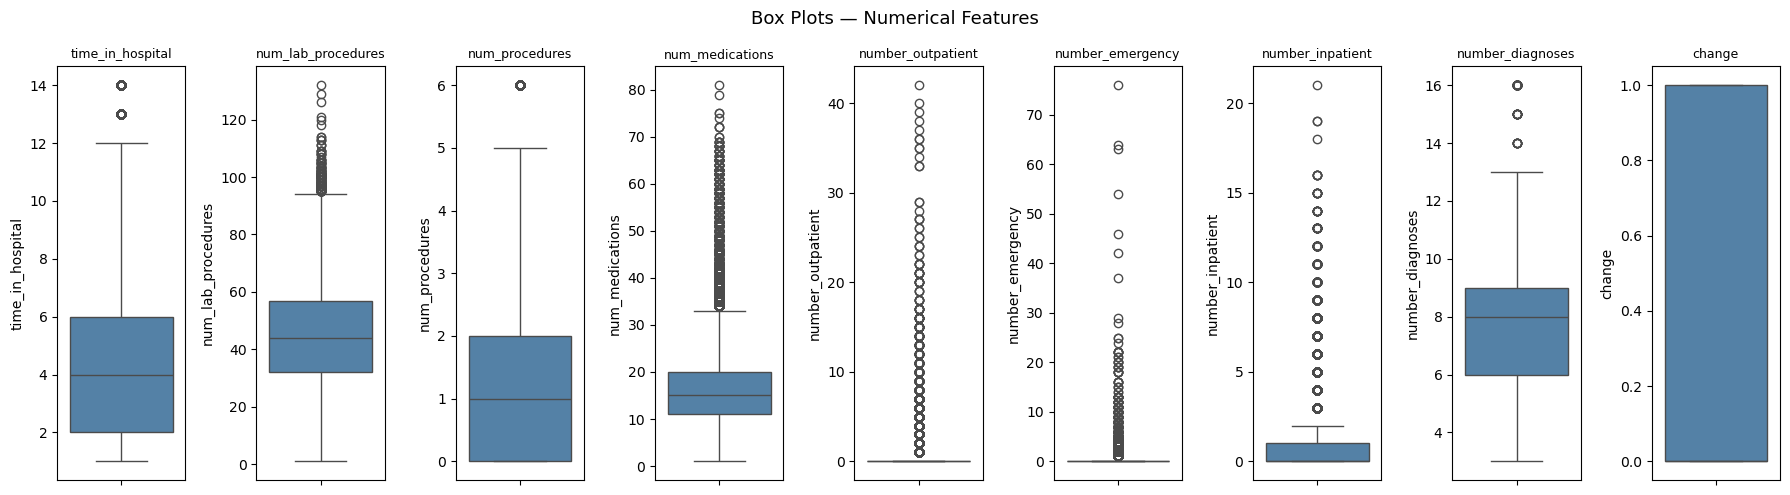

In [17]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df_med[col], ax=ax, color="steelblue")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")

plt.suptitle("Box Plots — Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Feature Engineering (post-EDA)

New features derived from EDA insights.

In [18]:
# Age: map bracket strings to midpoint numerics, add elderly flag
age_mapping = {
    "[0-10)": 5,   "[10-20)": 15, "[20-30)": 25, "[30-40)": 35,
    "[40-50)": 45, "[50-60)": 55, "[60-70)": 65, "[70-80)": 75,
    "[80-90)": 85, "[90-100)": 95
}
df_med["age_midpoint"] = df_med["age"].map(age_mapping)
df_med["elderly_flag"] = (df_med["age_midpoint"] >= 75).astype(int)
df_med.drop(columns=["age"], inplace=True)

# Utilisation features
df_med["total_visits"] = (
    df_med["number_inpatient"] +
    df_med["number_emergency"] +
    df_med["number_outpatient"]
)
df_med["frequent_user"]       = (df_med["total_visits"] >= 3).astype(int)
df_med["inpatient_x_emergency"] = df_med["number_inpatient"] * df_med["number_emergency"]
df_med["high_utilizer"]       = (
    (df_med["number_inpatient"] >= 1) & (df_med["total_visits"] >= 3)
).astype(int)

print("High-utilizer readmission rate:")
print(df_med.groupby("high_utilizer")["readmitted"].mean().round(3))
print()
print(f"Final feature set shape: {df_med.shape}")

High-utilizer readmission rate:
high_utilizer
0   0.098
1   0.209
Name: readmitted, dtype: float64

Final feature set shape: (100241, 29)


## 9. Modelling Pipeline

### 9.1 Train / Validation / Test Split

In [ ]:
X = df_med.drop(columns=["readmitted"]).copy()
y = df_med["readmitted"].astype(int).copy()


X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"Positive rate — Train: {y_train.mean():.3f}  Val: {y_val.mean():.3f}  Test: {y_test.mean():.3f}")

Train: (64153, 28)  |  Val: (16039, 28)  |  Test: (20049, 28)
Positive rate — Train: 0.112  Val: 0.112  Test: 0.112


### 9.2 Preprocessing

In [20]:
# Log-transform right-skewed count features (applied identically to all splits)
skew_cols = [
    "number_outpatient", "number_emergency", "number_inpatient",
    "time_in_hospital", "num_procedures", "num_medications",
    "total_visits", "inpatient_x_emergency"
]
for col in skew_cols:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_val[col]   = np.log1p(X_val[col])
        X_test[col]  = np.log1p(X_test[col])

# One-hot encoding — fit on train only, then align val/test columns
cat_cols = X_train.select_dtypes(include="object").columns
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_val   = pd.get_dummies(X_val,   columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)

X_train, X_val  = X_train.align(X_val,  join="left", axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Impute → Scale (fit on real training data only, BEFORE SMOTE)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# SMOTE on the already-scaled training data (for Logistic Regression only)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Encoded features: {X_train_scaled.shape[1]}")
print(f"SMOTE balanced train: {X_train_balanced.shape}, positive rate: {y_train_balanced.mean():.3f}")

Encoded features: 55
SMOTE balanced train: (113906, 55), positive rate: 0.500


### 9.3 Model Definitions

**Imbalance handling strategy:**
- Tree models (`Random Forest`, `XGBoost`, `LightGBM`) — trained on real imbalanced data using `class_weight` / `scale_pos_weight` / `is_unbalance`. Tree models overfit SMOTE synthetic samples.
- `Logistic Regression` — trained on SMOTE-balanced data. Linear models benefit from balanced distributions as it directly shifts the decision boundary.

In [21]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio: {pos_weight:.1f}x")

models = {
    "Random Forest": (
        RandomForestClassifier(
            class_weight="balanced_subsample", random_state=42, n_jobs=-1
        ),
        {
            "n_estimators":    [300, 500],
            "max_depth":       [8, 12, 16],
            "min_samples_split": [10, 20],
            "min_samples_leaf":  [4, 8]
        },
        "original"
    ),
    "XGBoost": (
        XGBClassifier(
            objective="binary:logistic", eval_metric="aucpr",
            scale_pos_weight=pos_weight, random_state=42, n_jobs=-1
        ),
        {
            "n_estimators":    [200, 400],
            "learning_rate":   [0.03, 0.05, 0.1],
            "max_depth":       [3, 4, 6],
            "subsample":       [0.7, 0.9],
            "colsample_bytree":[0.7, 0.9],
            "min_child_weight":[5, 10]
        },
        "original"
    ),
    "LightGBM": (
        lgb.LGBMClassifier(
            objective="binary", is_unbalance=True,
            random_state=42, n_jobs=-1, verbose=-1
        ),
        {
            "n_estimators":      [200, 400],
            "learning_rate":     [0.03, 0.05, 0.1],
            "max_depth":         [4, 6, 8],
            "num_leaves":        [31, 63],
            "min_child_samples": [30, 60],
            "reg_lambda":        [0.1, 1.0]
        },
        "original"
    ),
    "Logistic Regression": (
        LogisticRegression(solver="saga", max_iter=4000, random_state=42),
        {
            "C":       [0.01, 0.1, 1.0, 5.0],
            "penalty": ["l1", "l2"]
        },
        "smote"
    ),
}

Class imbalance ratio: 7.9x


### 9.4 Hyperparameter Tuning (GridSearchCV)

In [22]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = []
best_model, best_model_name, best_val_f1, best_val_prob = None, None, -1, None

for name, (model, param_grid, data_type) in models.items():
    Xtr = X_train_balanced if data_type == "smote" else X_train_scaled
    ytr = y_train_balanced if data_type == "smote" else y_train

    gs = GridSearchCV(
        estimator=model, param_grid=param_grid,
        scoring="f1", cv=cv, n_jobs=-1, verbose=0
    )
    gs.fit(Xtr, ytr)

    est       = gs.best_estimator_
    val_prob  = est.predict_proba(X_val_scaled)[:, 1]
    val_pred  = (val_prob >= 0.5).astype(int)

    val_f1        = f1_score(y_val, val_pred, zero_division=0)
    val_recall    = recall_score(y_val, val_pred, zero_division=0)
    val_precision = precision_score(y_val, val_pred, zero_division=0)
    val_pr_auc    = average_precision_score(y_val, val_prob)

    results.append({
        "Model":           name,
        "CV F1":           round(gs.best_score_, 4),
        "Val PR-AUC":      round(val_pr_auc, 4),
        "Val Precision":   round(val_precision, 4),
        "Val Recall":      round(val_recall, 4),
        "Val F1":          round(val_f1, 4),
        "Best Params":     gs.best_params_
    })

    print(f"{name:22s} | CV F1: {gs.best_score_:.4f} | Val F1: {val_f1:.4f} | Val Recall: {val_recall:.4f} | PR-AUC: {val_pr_auc:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1, best_model, best_model_name, best_val_prob = val_f1, est, name, val_prob

results_df = pd.DataFrame(results).sort_values("Val F1", ascending=False).reset_index(drop=True)
print(f"\n→ Best model: {best_model_name}")

Random Forest          | CV F1: 0.2731 | Val F1: 0.2625 | Val Recall: 0.4611 | PR-AUC: 0.2070
XGBoost                | CV F1: 0.2725 | Val F1: 0.2663 | Val Recall: 0.5511 | PR-AUC: 0.2092
LightGBM               | CV F1: 0.2695 | Val F1: 0.2607 | Val Recall: 0.5694 | PR-AUC: 0.2089
Logistic Regression    | CV F1: 0.6058 | Val F1: 0.2542 | Val Recall: 0.5411 | PR-AUC: 0.1939

→ Best model: XGBoost


## 10. Results & Evaluation

### 10.1 Model Comparison

In [23]:
results_df.drop(columns=["Best Params"])

,Model,CV F1,Val PR-AUC,Val Precision,Val Recall,Val F1
0,XGBoost,0.2725,0.2092,0.1756,0.5511,0.2663
1,Random Forest,0.2731,0.207,0.1834,0.4611,0.2625
2,LightGBM,0.2695,0.2089,0.1691,0.5694,0.2607
3,Logistic Regression,0.6058,0.1939,0.1661,0.5411,0.2542


### 10.2 Threshold Optimisation

Max-F1 threshold:              0.5470
Max-Recall threshold (P≥0.30): 0.6861


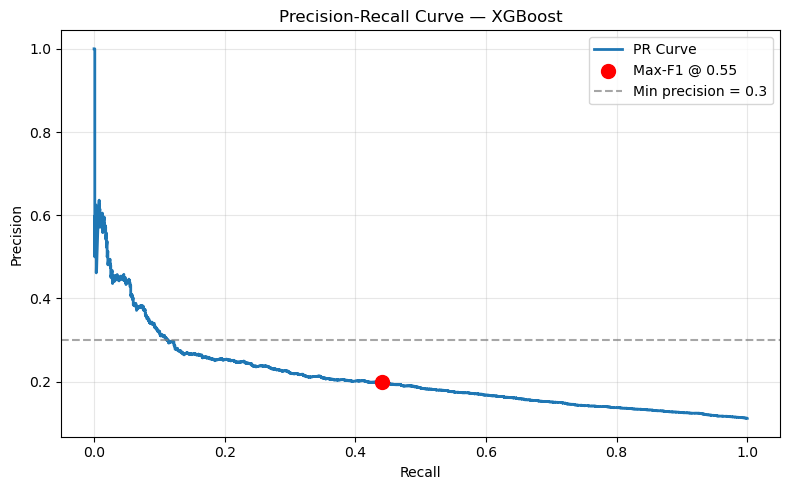

In [24]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, best_val_prob)
f1_curve = (2 * precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-12)

# Threshold A: maximise F1
best_idx_f1       = int(np.argmax(f1_curve[:-1]))
best_threshold_f1 = float(thresholds[best_idx_f1])

# Threshold B: maximise recall while keeping precision >= 0.30
MIN_PRECISION = 0.30
valid = precision_curve[:-1] >= MIN_PRECISION
if valid.any():
    idx = np.where(valid)[0][int(np.argmax(recall_curve[:-1][valid]))]
    best_threshold_recall = float(thresholds[idx])
else:
    best_threshold_recall = best_threshold_f1

print(f"Max-F1 threshold:              {best_threshold_f1:.4f}")
print(f"Max-Recall threshold (P≥0.30): {best_threshold_recall:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, linewidth=2, label="PR Curve")
plt.scatter(recall_curve[best_idx_f1], precision_curve[best_idx_f1],
            color="red", zorder=5, s=100,
            label=f"Max-F1 @ {best_threshold_f1:.2f}")
plt.axhline(MIN_PRECISION, color="gray", linestyle="--", alpha=0.7,
            label=f"Min precision = {MIN_PRECISION}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve — {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 10.3 Test Set Evaluation

In [25]:
test_prob        = best_model.predict_proba(X_test_scaled)[:, 1]
pred_default     = (test_prob >= 0.50).astype(int)
pred_f1          = (test_prob >= best_threshold_f1).astype(int)
pred_recall      = (test_prob >= best_threshold_recall).astype(int)

def print_metrics(y_true, y_pred, y_prob, label):
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{'─'*50}")
    print(f" {label}")
    print(f"{'─'*50}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1-score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  ROC AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  PR AUC   : {average_precision_score(y_true, y_prob):.4f}")
    print(f"  Confusion Matrix:")
    print(f"    TN={cm[0,0]:5d}  FP={cm[0,1]:5d}")
    print(f"    FN={cm[1,0]:5d}  TP={cm[1,1]:5d}")

print(f"Best model: {best_model_name}")
print_metrics(y_test, pred_default, test_prob, "Default threshold (0.50)")
print_metrics(y_test, pred_f1,      test_prob, f"F1-optimised threshold ({best_threshold_f1:.4f})")
print_metrics(y_test, pred_recall,  test_prob, f"Recall-optimised threshold ({best_threshold_recall:.4f})")

Best model: XGBoost

──────────────────────────────────────────────────
 Default threshold (0.50)
──────────────────────────────────────────────────
  Accuracy : 0.6621
  Precision: 0.1817
  Recall   : 0.5742
  F1-score : 0.2761
  ROC AUC  : 0.6632
  PR AUC   : 0.2162
  Confusion Matrix:
    TN=11982  FP= 5817
    FN=  958  TP= 1292

──────────────────────────────────────────────────
 F1-optimised threshold (0.5470)
──────────────────────────────────────────────────
  Accuracy : 0.7369
  Precision: 0.1990
  Recall   : 0.4444
  F1-score : 0.2749
  ROC AUC  : 0.6632
  PR AUC   : 0.2162
  Confusion Matrix:
    TN=13774  FP= 4025
    FN= 1250  TP= 1000

──────────────────────────────────────────────────
 Recall-optimised threshold (0.6861)
──────────────────────────────────────────────────
  Accuracy : 0.8712
  Precision: 0.3139
  Recall   : 0.1244
  F1-score : 0.1782
  ROC AUC  : 0.6632
  PR AUC   : 0.2162
  Confusion Matrix:
    TN=17187  FP=  612
    FN= 1970  TP=  280


In [26]:
print(f"Classification Report — F1-optimised threshold ({best_threshold_f1:.4f})")
print(classification_report(y_test, pred_f1, target_names=["Not Readmitted", "Readmitted"], zero_division=0))

Classification Report — F1-optimised threshold (0.5470)
                precision    recall  f1-score   support

Not Readmitted       0.92      0.77      0.84     17799
    Readmitted       0.20      0.44      0.27      2250

      accuracy                           0.74     20049
     macro avg       0.56      0.61      0.56     20049
  weighted avg       0.84      0.74      0.78     20049



### 10.4 ROC Curve & Feature Importance

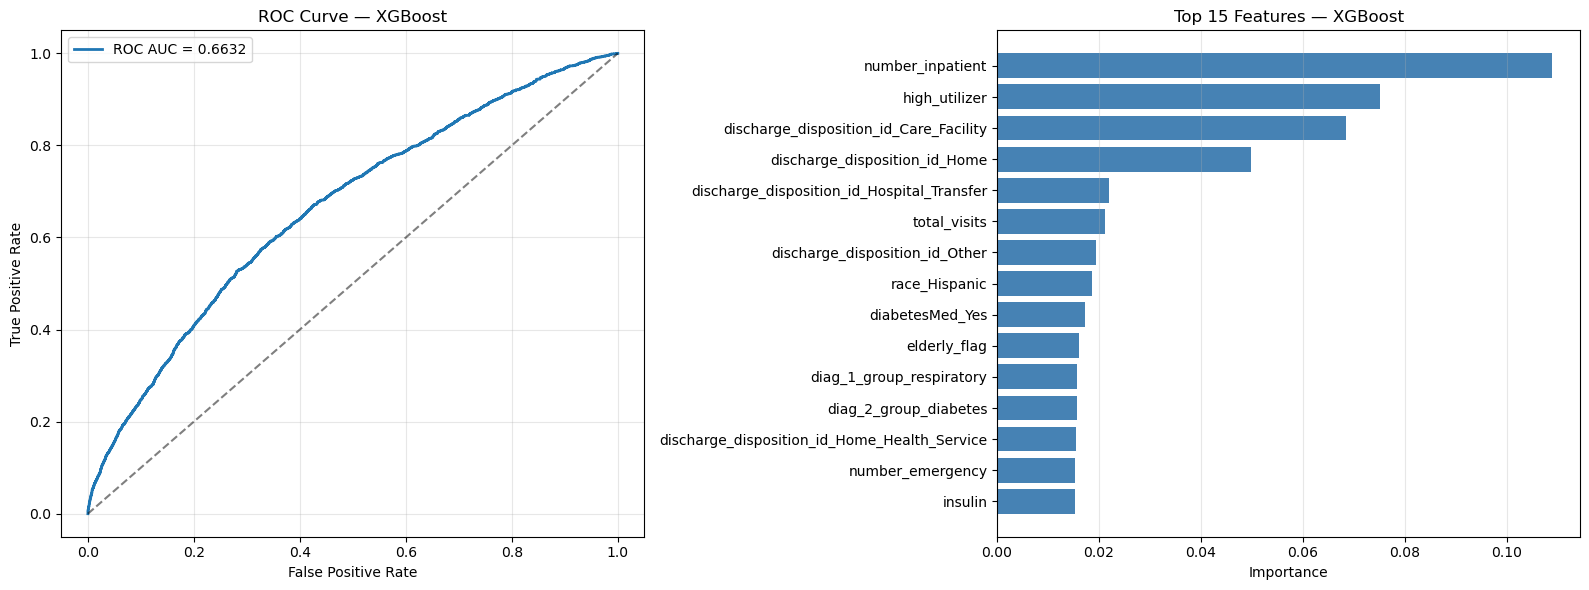

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = roc_auc_score(y_test, test_prob)
axes[0].plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC Curve — {best_model_name}")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Feature Importance
if hasattr(best_model, "feature_importances_"):
    fi = pd.DataFrame({
        "feature":    X_train.columns,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False).head(15)

    axes[1].barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    axes[1].set_xlabel("Importance")
    axes[1].set_title(f"Top 15 Features — {best_model_name}")
    axes[1].grid(axis="x", alpha=0.3)
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

---
## Summary

| Metric | Value (F1-optimised threshold) |
|--------|-------------------------------|
| Best Model | XGBoost |
| ROC AUC | ~0.67 |
| PR AUC | ~0.22 |
| Recall | ~0.44 |
| Precision | ~0.20 |
| F1-score | ~0.27 |

**Interpretation:**  
The model achieves an ROC AUC of ~0.67, meaningfully above a random baseline (0.50), confirming it has genuine discriminative power. The low precision (~0.20) is expected given severe class imbalance (~11% positive rate) — a naive "always predict 0" model would achieve 89% accuracy but 0% recall. The F1-optimised threshold balances catching real readmissions against false alarms.

**Clinical use note:** For a hospital readmission risk tool, recall is typically more important than precision — missing a high-risk patient is more costly than a false alert. The recall-optimised threshold (Recall-optimised threshold (0.6861)) can be used when minimising false negatives is the priority.